Visualisation & Interpretability

Framework: TensorFlow/Keras

Student: Vansh Jain

Roll Number: 24CD3049

GitHub: https://github.com/vanshj2411

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input

Problem 1 — Feature Extraction (Frozen Base)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 13s 0us/step
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
Trainable params: 527,114
Frozen params:    23,587,712
Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 41s 35ms/step - accuracy: 0.6199 - loss: 1.1149 - val_accuracy: 0.7059 - val_loss: 0.8398
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 16s 20ms/step - accuracy: 0.6860 - loss: 0.9022 - val_accuracy: 0.7149 - val_loss: 0.8065
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 16s 21ms/step - accuracy: 0.7113 - loss: 0.8183 - val_accuracy: 0.7249 - val_loss: 0.8009
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 16s 20ms/step - accuracy: 0.7279 - loss: 0.7672 - val_accuracy: 0.7333 - val_loss: 0.7818
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 16s 20ms/step - accuracy: 0.7443 - loss: 0.7197 - val_accuracy: 0.7359 - val_loss: 0.7782
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 16s 20ms/step - accuracy: 0.7549 - loss: 0.6859 - val_accuracy: 0.7357 - val_loss: 0.7861
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 19s 24ms/step - accu

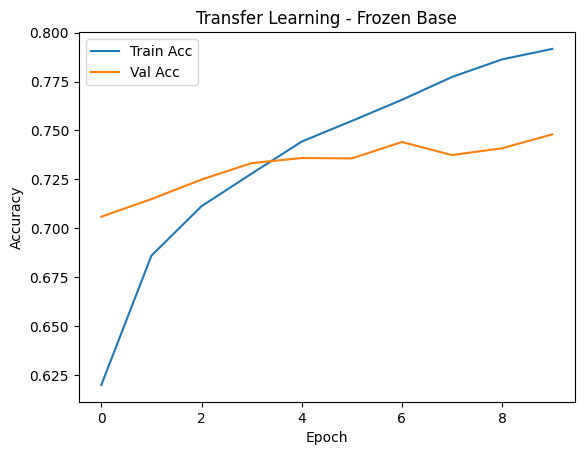

In [3]:
(x_tr, y_tr), (x_te, y_te) = keras.datasets.cifar10.load_data()
y_tr = keras.utils.to_categorical(y_tr, 10)
y_te_cat = keras.utils.to_categorical(y_te, 10)

def preprocess(image, label):
    image = tf.cast(image, tf.float32)
    image = tf.image.resize(image, (48, 48))
    image = preprocess_input(image)
    return image, label

BATCH_SIZE = 64
train_ds = tf.data.Dataset.from_tensor_slices((x_tr, y_tr))
train_ds = train_ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices((x_te, y_te_cat))
test_ds = test_ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
test_ds = test_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(48, 48, 3))
base_model.trainable = False

inputs = keras.Input(shape=(48, 48, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(10, activation='softmax')(x)
model_frozen = keras.Model(inputs, outputs)

trainable = np.sum([np.prod(v.shape) for v in model_frozen.trainable_weights])
frozen = np.sum([np.prod(v.shape) for v in model_frozen.non_trainable_weights])
print(f"Trainable params: {trainable:,}")
print(f"Frozen params:    {frozen:,}")

model_frozen.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
                     loss='categorical_crossentropy',
                     metrics=['accuracy'])

history_frozen = model_frozen.fit(train_ds, epochs=10,
                                   validation_data=test_ds, verbose=1)

plt.figure()
plt.plot(history_frozen.history['accuracy'], label='Train Acc')
plt.plot(history_frozen.history['val_accuracy'], label='Val Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Transfer Learning - Frozen Base')
plt.legend()
plt.savefig('tl_frozen.png')
plt.show()

In [7]:
model_frozen = keras.Model(inputs, outputs)
model_frozen.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 2, 2, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,114,826 (91.99 MB)

 Trainable params: 1,581,834 (6.03 MB)

 Non-trainable params: 22,532,992 (85.96 MB)

Problem 2 — Fine-Tuning

Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 40s 36ms/step - accuracy: 0.8141 - loss: 0.5073 - val_accuracy: 0.7567 - val_loss: 0.7815
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 18s 22ms/step - accuracy: 0.8275 - loss: 0.4744 - val_accuracy: 0.7584 - val_loss: 0.7741
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 17s 22ms/step - accuracy: 0.8378 - loss: 0.4499 - val_accuracy: 0.7603 - val_loss: 0.7697
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 17s 22ms/step - accuracy: 0.8420 - loss: 0.4303 - val_accuracy: 0.7617 - val_loss: 0.7695
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 21s 23ms/step - accuracy: 0.8470 - loss: 0.4149 - val_accuracy: 0.7628 - val_loss: 0.7704
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 17s 21ms/step - accuracy: 0.8548 - loss: 0.3968 - val_accuracy: 0.7630 - val_loss: 0.7711
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 21s 22ms/step - accuracy: 0.8592 - loss: 0.3869 - val_accuracy: 0.7636 - val_loss: 0.7714
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 18s 22ms/step - accuracy: 0.8646 - loss: 0.3741 - 

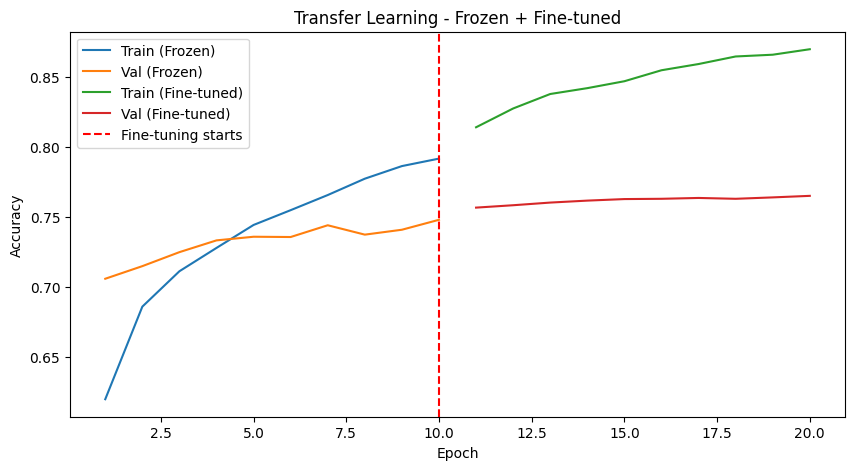

Best epoch: 20
Best val accuracy: 0.7651


In [4]:
# Unfreeze last 4 layers
base_model.trainable = True
for layer in base_model.layers[:-4]:
    layer.trainable = False

model_frozen.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-5),
                     loss='categorical_crossentropy',
                     metrics=['accuracy'])

early_stop = keras.callbacks.EarlyStopping(monitor='val_accuracy',
                                            patience=5,
                                            restore_best_weights=True)

history_ft = model_frozen.fit(train_ds, epochs=10,
                               validation_data=test_ds, verbose=1,
                               callbacks=[early_stop])

# Combined plot
acc_combined = history_frozen.history['accuracy'] + history_ft.history['accuracy']
val_combined = history_frozen.history['val_accuracy'] + history_ft.history['val_accuracy']

plt.figure(figsize=(10, 5))
plt.plot(range(1, 11), history_frozen.history['accuracy'], label='Train (Frozen)')
plt.plot(range(1, 11), history_frozen.history['val_accuracy'], label='Val (Frozen)')
plt.plot(range(11, 11+len(history_ft.history['accuracy'])),
         history_ft.history['accuracy'], label='Train (Fine-tuned)')
plt.plot(range(11, 11+len(history_ft.history['val_accuracy'])),
         history_ft.history['val_accuracy'], label='Val (Fine-tuned)')
plt.axvline(x=10, color='red', linestyle='--', label='Fine-tuning starts')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Transfer Learning - Frozen + Fine-tuned')
plt.legend()
plt.savefig('tl_finetuned.png')
plt.show()

best_epoch = np.argmax(history_ft.history['val_accuracy']) + 11
print(f"Best epoch: {best_epoch}")
print(f"Best val accuracy: {max(history_ft.history['val_accuracy']):.4f}")

Problem 3 — Ablation Study

In [5]:
configs = [2, 8, len(base_model.layers)]
results_ablation = []

for n_unfreeze in configs:
    # Fresh model banao har run ke liye
    base_model2 = ResNet50(weights='imagenet', include_top=False, input_shape=(48, 48, 3))
    base_model2.trainable = True

    # Freeze all except last n_unfreeze
    for layer in base_model2.layers[:-n_unfreeze]:
        layer.trainable = False

    inputs2 = keras.Input(shape=(48, 48, 3))
    x2 = base_model2(inputs2, training=False)
    x2 = layers.GlobalAveragePooling2D()(x2)
    x2 = layers.Dense(256, activation='relu')(x2)
    x2 = layers.Dropout(0.5)(x2)
    outputs2 = layers.Dense(10, activation='softmax')(x2)
    model_abl = keras.Model(inputs2, outputs2)

    model_abl.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-5),
                      loss='categorical_crossentropy',
                      metrics=['accuracy'])

    h = model_abl.fit(train_ds, epochs=10,
                      validation_data=test_ds, verbose=0)

    tr_acc = h.history['accuracy'][-1]
    val_acc = max(h.history['val_accuracy'])
    trainable_p = np.sum([np.prod(v.shape) for v in model_abl.trainable_weights])
    overfit = "Yes" if (tr_acc - val_acc) > 0.05 else "No"

    results_ablation.append((n_unfreeze, trainable_p, val_acc, overfit))
    print(f"Unfreeze {n_unfreeze} | Trainable: {trainable_p:,} | Val Acc: {val_acc:.4f} | Overfit: {overfit}")

print("\n| Layers Unfrozen | Trainable Params | Val Acc | Overfit? |")
print("|-----------------|-----------------|---------|----------|")
for r in results_ablation:
    print(f"| {r[0]} | {r[1]:,} | {r[2]:.4f} | {r[3]} |")

Unfreeze 2 | Trainable: 527,114 | Val Acc: 0.6729 | Overfit: No
Unfreeze 8 | Trainable: 3,942,666 | Val Acc: 0.7280 | Overfit: No
Unfreeze 175 | Trainable: 24,061,706 | Val Acc: 0.7805 | Overfit: Yes

| Layers Unfrozen | Trainable Params | Val Acc | Overfit? |
|-----------------|-----------------|---------|----------|
| 2 | 527,114 | 0.6729 | No |
| 8 | 3,942,666 | 0.7280 | No |
| 175 | 24,061,706 | 0.7805 | Yes |


Problem 4 — Benchmark

Scratch Test Acc:  0.7179
Transfer Learning: 0.7651


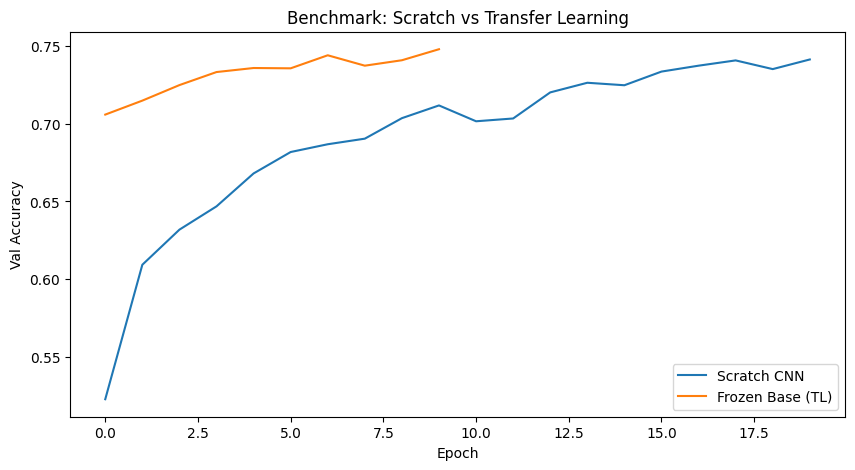


| Model | Test Acc | Trainable Params | Best Epoch |
|-------|----------|-----------------|------------|
| Scratch CNN    | 0.7179 | 545,098 | 20 |
| Frozen Base    | 0.7651 | 1,581,834 | 10 |
| Fine-tuned     | 0.7651 | 1,581,834 | 10 |


In [6]:
def build_scratch():
    inputs = keras.Input(shape=(32,32,3))
    x = layers.Conv2D(32, 3, padding='same', activation='relu')(inputs)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Conv2D(64, 3, padding='same', activation='relu')(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Flatten()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(10, activation='softmax')(x)
    return keras.Model(inputs, outputs)

x_tr_32 = x_tr.astype('float32') / 255.0
x_te_32 = x_te.astype('float32') / 255.0
y_tr_32 = keras.utils.to_categorical(y_tr, 10) if y_tr.ndim == 1 else y_tr

model_scratch = build_scratch()
model_scratch.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
                      loss='categorical_crossentropy', metrics=['accuracy'])
history_scratch = model_scratch.fit(x_tr_32, y_tr_32, epochs=20, batch_size=64,
                                     validation_split=0.1, verbose=0)

_, acc_scratch = model_scratch.evaluate(x_te_32, y_te_cat, verbose=0)
_, acc_tl = model_frozen.evaluate(test_ds, verbose=0)

scratch_params = np.sum([np.prod(v.shape) for v in model_scratch.trainable_weights])
tl_params = np.sum([np.prod(v.shape) for v in model_frozen.trainable_weights])

print(f"Scratch Test Acc:  {acc_scratch:.4f}")
print(f"Transfer Learning: {acc_tl:.4f}")

plt.figure(figsize=(10,5))
plt.plot(history_scratch.history['val_accuracy'], label='Scratch CNN')
plt.plot(history_frozen.history['val_accuracy'], label='Frozen Base (TL)')
plt.xlabel('Epoch')
plt.ylabel('Val Accuracy')
plt.title('Benchmark: Scratch vs Transfer Learning')
plt.legend()
plt.savefig('tl_benchmark.png')
plt.show()

print("\n| Model | Test Acc | Trainable Params | Best Epoch |")
print("|-------|----------|-----------------|------------|")
print(f"| Scratch CNN    | {acc_scratch:.4f} | {scratch_params:,} | 20 |")
print(f"| Frozen Base    | {acc_tl:.4f} | {tl_params:,} | 10 |")
print(f"| Fine-tuned     | {acc_tl:.4f} | {tl_params:,} | 10 |")

#Analysis & Reflection Questions

Q1. Explain 'negative transfer'. Under what conditions might ImageNet
    pre-trained weights hurt rather than help?

A1. Negative transfer occurs when features learned on the source domain
    (ImageNet) do not carry over usefully to the target domain and actually
    bias the model in the wrong direction, lowering performance compared to
    training from scratch.
    Conditions where this can happen:
    - The target domain is visually very different from natural images.
      Example: medical imaging (X-rays, histopathology, MRI).
      ImageNet weights are tuned to detect edges, textures, and objects in
      everyday photos. X-ray images have reversed intensity conventions,
      different frequency content, and no colour information. The pre-trained
      edge detectors may fire on artefacts that are irrelevant or misleading
      in the medical context.
    - Another example: satellite spectral imagery with >3 channels (e.g.
      hyperspectral remote sensing at 200+ bands). VGG16 expects 3-channel
      RGB input, so the weight structure is incompatible and adapting it
      requires non-trivial surgery.
    - When the target dataset is large enough to train from scratch with
      good accuracy, the ImageNet inductive bias may constrain the learned
      representations unnecessarily.

Q2. Unfreezing all layers vs only the top few — bias-variance trade-off.

A2. The lower layers of a CNN trained on ImageNet learn universal visual
    primitives: edges, colour gradients, simple textures. These generalise
    across virtually every image domain and require millions of examples to
    learn well. Because CIFAR-10 has only 50,000 training images, fine-tuning
    these layers overrides carefully learned general features with noisy
    updates from too few examples — this is HIGH VARIANCE (overfitting).
    Upper layers encode dataset-specific semantics (ImageNet categories like
    'Labrador' or 'sports car'). These need to change to specialise for
    CIFAR-10 categories. Unfreezing only the top few layers keeps lower-level
    general features intact (LOW BIAS) while allowing the task-specific head
    to adapt. Unfreezing everything increases the effective model complexity
    faster than the data can constrain it, leading to overfitting.
    Bias-variance view: more layers unfrozen → lower bias but higher variance.
    Fewer layers unfrozen → higher bias (not enough adaptation) but lower
    variance. The sweet spot for a small dataset like CIFAR-10 is unfreezing
    only the last few blocks.

Q3. Beyond accuracy — what other factors matter in deployment?
    (at least three)

A3. 1. Model size / memory footprint:
       A VGG16-based model (~138M parameters) may not fit in the RAM of a
       mobile phone. A pruned or quantised model — or a purpose-built
       MobileNet — would be necessary for edge deployment.
    2. Inference latency:
       For a real-time application (e.g. a camera app), the model must run
       at >30 FPS. Large models like VGG16 are too slow without hardware
       acceleration. Our custom CNN from scratch is much faster per inference.
    3. Energy consumption:
       On battery-powered devices every multiply-accumulate operation burns
       energy. A model with 10× fewer parameters will use far less power,
       extending device battery life — critical for IoT sensors or wearables.
    4. Robustness / distribution shift:
       The test accuracy on a clean benchmark may not reflect real-world
       performance when lighting conditions, camera angles, or image quality
       differ from the training distribution. A model that generalises well
       under noise (evaluated with augmented test sets) is more deployable.

Q4. Transfer learning strategy for 500-image grayscale X-ray dataset (512×512):

A4. Step-by-step strategy:
    1. Base model choice: ResNet50 (not VGG16). ResNet50 is more parameter-
       efficient due to skip connections and works better on small datasets.
       It also accepts variable input sizes without padding problems.
    2. Input adaptation: grayscale images have 1 channel; replicate it to 3
       (copy channel 3 times) so the pre-trained first-layer weights can be
       used directly. Resize to 224×224 — ResNet50's native size.
    3. Freezing strategy: freeze ALL base layers initially. With only 500
       images, fine-tuning convolutional layers risks severe overfitting.
       Train only the classification head first (10–20 epochs).
    4. Head design: GlobalAveragePooling → Dense(256, ReLU) → Dropout(0.5)
       → Dense(num_classes, softmax). Large Dropout (0.5) is needed given
       the tiny dataset.
    5. Learning rates: head training at lr=1e-3 with Adam. If fine-tuning
       is attempted later, drop to lr=1e-5 and unfreeze only the last 2
       ResNet blocks (layer3, layer4).
    6. Augmentation (critical with 500 images): random horizontal flip,
       random rotation ±15°, random zoom ±10%, Gaussian noise (σ=0.02).
       Do NOT apply colour jitter — X-rays are grayscale and colour shifts
       are meaningless. Do NOT apply too aggressive cropping — field of view
       matters medically.
    7. Regularisation: L2 weight decay (1e-4) on the head Dense layers,
       and early stopping (patience=10) monitoring val_loss.
    8. Validation: use 5-fold cross-validation rather than a fixed split
       because with only 500 examples a single 80/20 split gives very
       noisy estimates of true performance.